In [4]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as  plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
df=pd.read_csv("Credit_Risk_Data.csv")

In [6]:
print(df,10)

     Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0             0   67    male    2     own             NaN           little   
1             1   22  female    2     own          little         moderate   
2             2   49    male    1     own          little              NaN   
3             3   45    male    2    free          little           little   
4             4   53    male    2    free          little           little   
..          ...  ...     ...  ...     ...             ...              ...   
995         995   31  female    1     own          little              NaN   
996         996   40    male    3     own          little           little   
997         997   38    male    2     own          little              NaN   
998         998   23    male    2    free          little           little   
999         999   27    male    2     own        moderate         moderate   

     Credit amount  Duration              Purpose  Risk  
0    

In [7]:
df=df.dropna()

In [8]:
df=pd.get_dummies(df,drop_first=True)

In [9]:
print(df,10)

     Unnamed: 0  Age  Job  Credit amount  Duration  Sex_male  Housing_own  \
1             1   22    2           5951        48     False         True   
3             3   45    2           7882        42      True        False   
4             4   53    2           4870        24      True        False   
7             7   35    3           6948        36      True        False   
9             9   28    3           5234        30      True         True   
..          ...  ...  ...            ...       ...       ...          ...   
989         989   48    1           1743        24      True         True   
993         993   30    3           3959        36      True         True   
996         996   40    3           3857        30      True         True   
998         998   23    2           1845        45      True        False   
999         999   27    2           4576        45      True         True   

     Housing_rent  Saving accounts_moderate  Saving accounts_quite rich  ..

In [20]:
df=df.drop("Unnamed: 0", axis=1)


In [ ]:
#df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [21]:
X=df.drop("Risk_good", axis=1)
y=df["Risk_good"]

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [51]:
model=RandomForestClassifier(n_estimators=100)
model.fit(X_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [52]:
y_pred=model.predict(X_test)

In [53]:
accuracy=accuracy_score(y_test,y_pred)

In [54]:
print("Accuracy: ",accuracy)

Accuracy:  0.6952380952380952


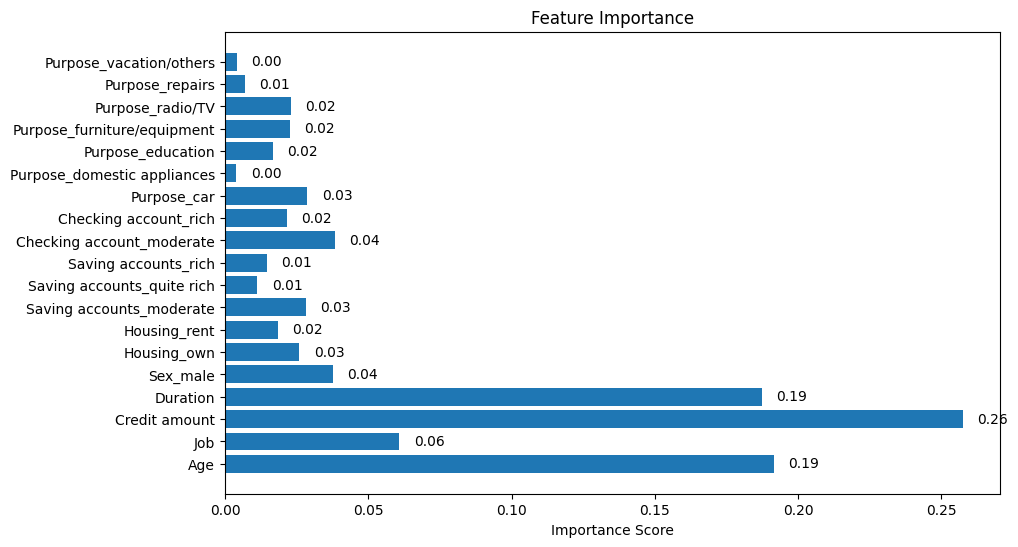

In [55]:

importance = model.feature_importances_
features = X.columns
plt.figure(figsize=(10,6))

plt.barh(features, importance)
for i, v in enumerate(importance):
    plt.text(v + 0.005, i, f"{v:.2f}", va='center')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

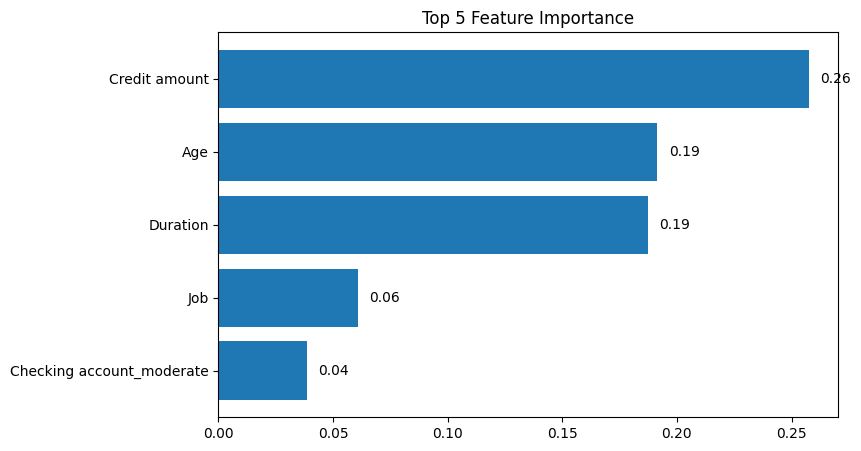

In [56]:

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
top_features =feature_importance.head(5)
plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])

for i, v in enumerate(top_features['Importance']):
    plt.text(v + 0.005, i, f"{v:.2f}", va='center')

plt.title("Top 5 Feature Importance")
plt.gca().invert_yaxis()
plt.show()


In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.66      0.50      0.57        42
        True       0.71      0.83      0.76        63

    accuracy                           0.70       105
   macro avg       0.68      0.66      0.67       105
weighted avg       0.69      0.70      0.69       105

